In [1]:
import os
import sys
from pathlib import Path
import numpy as np

# ── path setup: works from notebooks/ or from repo root ──────────────────────
REPO_ROOT = Path("__file__").resolve().parents[1] 
DATA_ROOT = REPO_ROOT / "data" / "processed" / "lars_data"

# override here if running on Kaggle/Colab with different mount path:
# DATA_ROOT = Path("/kaggle/input/lars-dataset/lars_data")

print(f"Repo root : {REPO_ROOT}")
print(f"Data root : {DATA_ROOT}")
print(f"Exists    : {DATA_ROOT.exists()}")

Repo root : D:\Desktop\aso_deep_seg
Data root : D:\Desktop\aso_deep_seg\data\processed\lars_data
Exists    : True


In [2]:
import sys
import os

sys.path.append(os.path.abspath("..")) 

In [ ]:
from deep_seg.scripts.lars_binary_dataset import WaterBinaryDataset

train_dataset = WaterBinaryDataset(DATA_ROOT, "train", image_size=640)
valid_dataset = WaterBinaryDataset(DATA_ROOT, "val", image_size=640)
test_dataset  = WaterBinaryDataset(DATA_ROOT, "test", image_size=640)

In [ ]:
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.v2 as T


# optional augmentations for testing
debug_aug = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
])

ds = WaterBinaryDataset(
    root=DATA_ROOT,
    split="train",
    image_size=640,
    augmentations=debug_aug,   # set to None if you want
)

print("dataset length:", len(ds))

sample = ds[0]

if isinstance(sample, tuple):
    image, mask = sample
    print("image shape :", image.shape)
    print("image dtype :", image.dtype)
    print("image min/max:", image.min().item(), image.max().item())

    print("mask shape  :", mask.shape)
    print("mask dtype  :", mask.dtype)
    print("mask unique :", torch.unique(mask))

else:
    image = sample
    print("image shape :", image.shape)
    print("image dtype :", image.dtype)
    print("image min/max:", image.min().item(), image.max().item())


# ---- visualize a few samples -------------------------------------------------
n_show = 4
fig, axes = plt.subplots(n_show, 3, figsize=(10, 3 * n_show))

for i in range(n_show):
    image, mask = ds[i]

    img_np = image.permute(1, 2, 0).cpu().numpy()
    mask_np = mask.squeeze(0).cpu().numpy()

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Image {i}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_np, cmap="gray")
    axes[i, 1].set_title(f"Mask {i} | unique={np.unique(mask_np)}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(img_np)
    axes[i, 2].imshow(mask_np, cmap="Reds", alpha=0.35)
    axes[i, 2].set_title(f"Overlay {i}")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [16]:
from deep_seg.scripts.water_segmentation_model import WaterSegmentationModel
from torchinfo import summary


model = WaterSegmentationModel("Unet", "resnet34", encoder_weights="imagenet",in_channels=3, out_classes=1)
batch_size = 16
summary(model, input_size=(batch_size, 1, 28, 28))

Layer (type:depth-idx)                             Output Shape              Param #
WaterSegmentationModel                             [16, 1, 28, 28]           --
├─Unet: 1-1                                        [16, 1, 28, 28]           --
│    └─ResNetEncoder: 2-1                          [16, 3, 28, 28]           --
│    │    └─Conv2d: 3-1                            [16, 64, 14, 14]          9,408
│    │    └─BatchNorm2d: 3-2                       [16, 64, 14, 14]          128
│    │    └─ReLU: 3-3                              [16, 64, 14, 14]          --
│    │    └─MaxPool2d: 3-4                         [16, 64, 7, 7]            --
│    │    └─Sequential: 3-5                        [16, 64, 7, 7]            221,952
│    │    └─Sequential: 3-6                        [16, 128, 4, 4]           1,116,416
│    │    └─Sequential: 3-7                        [16, 256, 2, 2]           6,822,400
│    │    └─Sequential: 3-8                        [16, 512, 1, 1]           13,114,368
│   

ResNetEncoder(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_runn


(process:24160): Pango-WARNING **: 01:24:18.410: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


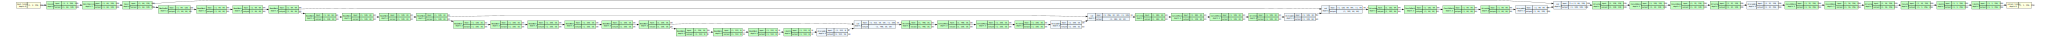


(process:18592): Pango-WARNING **: 01:24:18.549: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


'seg_model_graph.png'

In [ ]:
from deep_seg.scripts.water_segmentation_model import WaterSegmentationModel


model = WaterSegmentationModel("Unet", "resnet34", encoder_weights="imagenet",in_channels=3, out_classes=1)
print(model.model.encoder)
print(model.model.decoder)
print(model.model.segmentation_head)




from torchview import draw_graph
import torch

# your segmentation model (smp UNet etc.)
core = model.model  # WaterSegmentationModel.model

# Dummy input with correct size
x = torch.randn(1, 3, 256, 256)  # adapt to your config

# expand_nested=True expands encoder/decoder blocks
graph = draw_graph(core, input_size=x.shape, expand_nested=False, graph_dir="LR")


# In notebook
display(graph.visual_graph)
graph.visual_graph.render("seg_model_graph", format="png")